In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns

In [2]:
purchases = pd.read_csv('QVI_purchase_behaviour.csv')
purchases.head(10)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


In [3]:
transactions = pd.read_csv('QVI_transaction_data_cleandates.csv')
transactions.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,10/17/2018,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,5/14/2019,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,5/20/2019,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,8/17/2018,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,8/18/2018,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,5/19/2019,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,5/16/2019,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,5/16/2019,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,8/20/2018,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,8/18/2018,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [4]:
transactions_expanded = transactions.merge(purchases, how='left', on='LYLTY_CARD_NBR')
transactions_expanded.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,10/17/2018,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,5/14/2019,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,5/20/2019,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,8/17/2018,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,8/18/2018,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget
5,5/19/2019,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1,MIDAGE SINGLES/COUPLES,Budget
6,5/16/2019,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,MIDAGE SINGLES/COUPLES,Budget
7,5/16/2019,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,MIDAGE SINGLES/COUPLES,Budget
8,8/20/2018,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,MIDAGE SINGLES/COUPLES,Budget
9,8/18/2018,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,MIDAGE SINGLES/COUPLES,Budget


In [5]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  object 
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(5), object(2)
memory usage: 14.1+ MB


In [6]:
purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [7]:
transactions_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              264836 non-null  object 
 1   STORE_NBR         264836 non-null  int64  
 2   LYLTY_CARD_NBR    264836 non-null  int64  
 3   TXN_ID            264836 non-null  int64  
 4   PROD_NBR          264836 non-null  int64  
 5   PROD_NAME         264836 non-null  object 
 6   PROD_QTY          264836 non-null  int64  
 7   TOT_SALES         264836 non-null  float64
 8   LIFESTAGE         264836 non-null  object 
 9   PREMIUM_CUSTOMER  264836 non-null  object 
dtypes: float64(1), int64(5), object(4)
memory usage: 16.2+ MB


In [8]:
transactions_expanded.describe()

,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [9]:
transactions_expanded.isna().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [10]:
box = sns.boxplot(x=transactions_expanded['PROD_QTY'])
g = plt.gca()
plt.xlabel('Number of Products')

<class 'NameError'>: name 'sns' is not defined

In [11]:
transactions_expanded[transactions_expanded['PROD_QTY'] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
69762,8/19/2018,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,OLDER FAMILIES,Premium
69763,5/20/2019,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,OLDER FAMILIES,Premium


Loyalty card number '226600' has two seperate transactions for 200 bags of doritos chips. This seems unlikely so we should check the validity of these transactions. For now we will record the outlier and set them to the mean of the dataset, '2', which not only puts it in line with the rest of the data. It could also be the biproduct of an input error which added two extra zeros onto the product quantity. 

In [12]:
transactions_expanded.loc[69762,'PROD_QTY'] = 2
transactions_expanded.loc[69762]

DATE                                       8/19/2018
STORE_NBR                                        226
LYLTY_CARD_NBR                                226000
TXN_ID                                        226201
PROD_NBR                                           4
PROD_NAME           Dorito Corn Chp     Supreme 380g
PROD_QTY                                           2
TOT_SALES                                      650.0
LIFESTAGE                             OLDER FAMILIES
PREMIUM_CUSTOMER                             Premium
Name: 69762, dtype: object

In [13]:
transactions_expanded.loc[69763,'PROD_QTY'] = 2
transactions_expanded.loc[69763]

DATE                                       5/20/2019
STORE_NBR                                        226
LYLTY_CARD_NBR                                226000
TXN_ID                                        226210
PROD_NBR                                           4
PROD_NAME           Dorito Corn Chp     Supreme 380g
PROD_QTY                                           2
TOT_SALES                                      650.0
LIFESTAGE                             OLDER FAMILIES
PREMIUM_CUSTOMER                             Premium
Name: 69763, dtype: object

In [14]:
transactions_expanded[transactions_expanded['PROD_QTY'] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER


In [15]:
transactions_expanded.describe()

,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,135.08011,1.355495e+05,1.351583e+05,56.583157,1.905813,7.304200
std,76.78418,8.057998e+04,7.813303e+04,32.826638,0.343435,3.083226
min,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,272.00000,2.373711e+06,2.415841e+06,114.000000,5.000000,650.000000


In [16]:
transactions_expanded['DATE'] = pd.to_datetime(transactions_expanded['DATE'])
transactions_expanded.info('DATE')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264836 non-null  datetime64[ns]
 1   STORE_NBR         264836 non-null  int64         
 2   LYLTY_CARD_NBR    264836 non-null  int64         
 3   TXN_ID            264836 non-null  int64         
 4   PROD_NBR          264836 non-null  int64         
 5   PROD_NAME         264836 non-null  object        
 6   PROD_QTY          264836 non-null  int64         
 7   TOT_SALES         264836 non-null  float64       
 8   LIFESTAGE         264836 non-null  object        
 9   PREMIUM_CUSTOMER  264836 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 17.2+ MB


In [17]:
product_words = (
    transactions['PROD_NAME']
        .str.split('\n')   # split each string by newline
        .explode()         # turn list elements into separate rows
        .dropna()          # optional: remove NaN values
        .unique()          # get unique values
)

product_words = (
    pd.Series(product_words)
        .reset_index(drop=True)
        .to_frame(name='words')
)
product_words.sort_values(by=['words'])
product_words

,words
0,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g
...,...
109,Red Rock Deli Chikn&Garlic Aioli 150g
110,RRD SR Slow Rst Pork Belly 150g
111,RRD Pc Sea Salt 165g
112,Smith Crinkle Cut Bolognese 150g


In [18]:
salsa_dips = transactions_expanded[transactions_expanded['PROD_NAME'].str.contains('Salsa') & transactions_expanded['PROD_NAME'].str.contains('Dip')]

In [19]:
salsa_dips.drop_duplicates('PROD_NBR')

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1,MIDAGE SINGLES/COUPLES,Budget
71,2018-08-15,94,94233,93956,65,Old El Paso Salsa Dip Chnky Tom Ht300g,1,5.1,MIDAGE SINGLES/COUPLES,Budget
87,2018-08-15,116,116184,120270,59,Old El Paso Salsa Dip Tomato Med 300g,1,5.1,MIDAGE SINGLES/COUPLES,Budget


In [20]:
transactions_expanded = transactions_expanded.drop(transactions_expanded[transactions_expanded['PROD_NBR'] == 57].index)
transactions_expanded = transactions_expanded.drop(transactions_expanded[transactions_expanded['PROD_NBR'] == 65].index)
transactions_expanded = transactions_expanded.drop(transactions_expanded[transactions_expanded['PROD_NBR'] == 59].index)

In [21]:
transactions_expanded[transactions_expanded['PROD_NBR'] == 57] 

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER


In [22]:
product_words = (
    transactions['PROD_NAME']
        .str.split('\n')   # split each string by newline
        .explode()         # turn list elements into separate rows
        .dropna()          # optional: remove NaN values
        .unique()          # get unique values
)

product_words = (
    pd.Series(product_words)
        .reset_index(drop=True)
        .to_frame(name='words')
)
product_words.sort_values(by=['words'])
product_words

,words
0,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g
...,...
109,Red Rock Deli Chikn&Garlic Aioli 150g
110,RRD SR Slow Rst Pork Belly 150g
111,RRD Pc Sea Salt 165g
112,Smith Crinkle Cut Bolognese 150g


In [23]:
salsa_dips = transactions_expanded[transactions_expanded['PROD_NAME'].str.contains('Salsa')]
salsa_dips

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
32,2019-05-20,45,45127,41122,64,Red Rock Deli SR Salsa & Mzzrlla 150g,2,5.4,MIDAGE SINGLES/COUPLES,Budget
44,2018-08-18,56,56013,50090,39,Smiths Crinkle Cut Tomato Salsa 150g,1,2.6,MIDAGE SINGLES/COUPLES,Budget
63,2019-05-15,82,82480,82047,101,Doritos Salsa Medium 300g,1,2.6,MIDAGE SINGLES/COUPLES,Budget
74,2018-08-16,97,97159,97271,35,Woolworths Mild Salsa 300g,5,7.5,MIDAGE SINGLES/COUPLES,Budget
158,2018-08-18,214,214277,213883,76,Woolworths Medium Salsa 300g,1,1.5,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...
264663,2018-08-24,265,265018,263318,101,Doritos Salsa Medium 300g,1,2.6,YOUNG SINGLES/COUPLES,Premium
264678,2019-03-30,265,265111,263428,35,Woolworths Mild Salsa 300g,1,1.5,YOUNG SINGLES/COUPLES,Premium
264719,2018-10-28,266,266278,264104,39,Smiths Crinkle Cut Tomato Salsa 150g,1,2.6,YOUNG SINGLES/COUPLES,Premium
264734,2019-01-11,267,267324,264374,41,Doritos Salsa Mild 300g,1,2.6,YOUNG SINGLES/COUPLES,Premium


In [24]:
salsa_dips_mask = ~transactions_expanded['PROD_NAME'].str.contains('Salsa',na=False)
transactions_expanded_no_salsa = transactions_expanded[salsa_dips_mask]
transactions_expanded_no_salsa

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium


In [25]:
transactions_expanded_no_salsa.to_csv('QVI_transaction_data_cleaned.csv',index=False)

In [51]:
number_of_transactions = (
    transactions_expanded.groupby(['DATE']).size().reset_index(name='total_transactions')
)
number_of_transactions

,DATE,total_transactions
0,2018-07-01,693
1,2018-07-02,677
2,2018-07-03,695
3,2018-07-04,689
4,2018-07-05,679
...,...,...
359,2019-06-26,689
360,2019-06-27,691
361,2019-06-28,701
362,2019-06-29,722


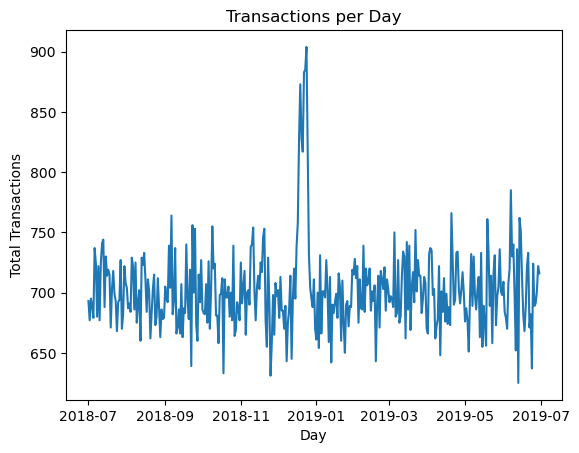

In [52]:
x = number_of_transactions['DATE']
y = number_of_transactions['total_transactions']

plt.plot(x,y)
plt.xlabel('Day')
plt.ylabel('Total Transactions')
plt.title('Transactions per Day')
plt.show()

In [68]:
number_of_transactions['DATE'] = pd.to_datetime(number_of_transactions['DATE'])

december_data = number_of_transactions[
    number_of_transactions['DATE'].dt.month == 12
]

full_range = pd.date_range(
    start=december_data['DATE'].min(),
    end=december_data['DATE'].max(),
    freq='D'
)

december_data = (
    december_data
        .set_index('DATE')
        .reindex(full_range, fill_value=0)
        .rename_axis('DATE')
        .reset_index()
)
december_data

,DATE,total_transactions,MONTH
0,2018-12-01,702,12
1,2018-12-02,679,12
2,2018-12-03,713,12
3,2018-12-04,685,12
4,2018-12-05,685,12
5,2018-12-06,670,12
6,2018-12-07,689,12
7,2018-12-08,643,12
8,2018-12-09,675,12
9,2018-12-10,686,12


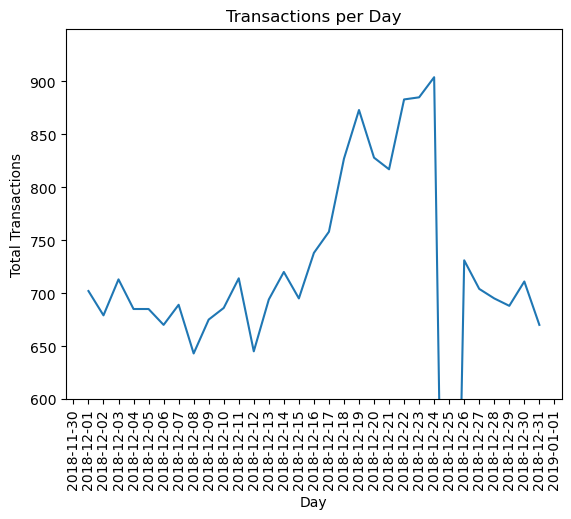

In [71]:
import matplotlib.dates as mdates

x = december_data['DATE']
y = december_data['total_transactions']

plt.plot(x,y)
plt.xlabel('Day')
plt.ylabel('Total Transactions')
plt.title('Transactions per Day')

plt.xticks(rotation=90)
plt.ylim(600,)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.show()